[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ChrisW09/Quantitative-Research-Methods/blob/main/Projects/project_2_college/project_2_starter.ipynb)

*This notebook runs on Colab as-is. The badge link above and the `GITHUB_RAW` line in the setup cell already point to this repository, so everything installs and loads automatically.*

# Project 2 — Five numbers or seventeen?
## What drives out-of-state tuition, and what does simplicity cost?

**Course:** Quantitative Research Methods
**Instructor:** Prof. Dr. Christoph Weisser, HSBI
**Source:** James, Witten, Hastie, Tibshirani & Taylor (2023), *An Introduction to Statistical Learning, with Applications in Python*, Springer. Companion code at [statlearning.com](https://www.statlearning.com).

Read `README.md` in this folder first — it contains the brief, the rules, and the list of numbers your memo must report.

**Goal.** A university consortium must publish a model of out-of-state tuition. A colleague has fitted all seventeen available predictors and claims the model cannot be improved on; the board wants **five variables** it can defend in public. You must produce the best model you can honestly evaluate, produce a five-variable model, and **price the restriction in dollars of RMSE** — then recommend one of them.

This notebook does the parts that must be identical for everyone: it loads the data, seals a test set, computes the baseline you have to beat, and provides the two helpers you will score with. Everything from `## Step 1` onwards is yours.

## Setup

Run this cell once. The `ISLP` package can be installed with `pip install ISLP`. As an alternative, the same data sets are available as CSVs in the workspace's `ALL CSV FILES - 2nd Edition` folder.


> **Google Colab:** this notebook also runs on Colab out of the box — the setup cell below installs any missing packages and downloads the data automatically.


In [1]:
# --- Setup: runs locally AND on Google Colab --------------------------------
# Silence only the spurious 'encountered in matmul' RuntimeWarnings that the macOS
# Accelerate BLAS emits; real warnings (deprecations, model caveats) stay visible.
import warnings
warnings.filterwarnings('ignore', message='.*encountered in matmul', category=RuntimeWarning)
import importlib.util, os, subprocess, sys

IN_COLAB = 'google.colab' in sys.modules

def _ensure(pkg, import_name=None):
    """pip-install pkg (quietly) if its import is missing."""
    if importlib.util.find_spec(import_name or pkg) is None:
        subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', pkg], check=False)

if IN_COLAB:  # Colab ships numpy/pandas/sklearn/statsmodels; add course extras
    for _pkg, _imp in [('ISLP', 'ISLP')]:
        _ensure(_pkg, _imp)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(2024)
plt.rcParams['figure.dpi'] = 110

try:
    from ISLP import load_data
    HAVE_ISLP = True
except ImportError:
    HAVE_ISLP = False
    print('ISLP not installed; using CSV / URL fallbacks.')

# Local CSV location (repo layout first, then legacy paths, then a data/ cache).
_CANDIDATES = ['../ALL CSV FILES - 2nd Edition',
               'ALL CSV FILES - 2nd Edition',
               '../../ALL CSV FILES - 2nd Edition', 'data']
CSV = next((p for p in _CANDIDATES if os.path.isdir(p)), 'data')

# GITHUB_RAW lets a fresh Colab runtime fetch any
# CSV that is neither in ISLP nor already local (spaces in the folder -> %20).
GITHUB_RAW = ('https://raw.githubusercontent.com/ChrisW09/Quantitative-Research-Methods/main/'
              'ALL%20CSV%20FILES%20-%202nd%20Edition')

# The four datasets NOT in the ISLP package -> load from the book's official
# site so the notebook works on a fresh Colab even before the repo is published.
KNOWN_URLS = {
    'Advertising': 'https://www.statlearning.com/s/Advertising.csv',
    'Heart':       'https://www.statlearning.com/s/Heart.csv',
    'Income1':     'https://www.statlearning.com/s/Income1.csv',
    'Income2':     'https://www.statlearning.com/s/Income2.csv',
}

def load(name, **read_csv_kwargs):
    """Load a course dataset. Order: ISLP package -> R datasets -> local CSV
    -> official book URL -> your GitHub repo. Works locally and on Colab."""
    if HAVE_ISLP:
        try:
            return load_data(name)
        except Exception:
            pass
    if name == 'USArrests':                       # classic R dataset, not in ISLP
        try:
            import statsmodels.api as sm
            return sm.datasets.get_rdataset('USArrests', 'datasets').data
        except Exception:
            pass
    path = f'{CSV}/{name}.csv'
    if os.path.exists(path):                      # running from the repo (local)
        return pd.read_csv(path, **read_csv_kwargs)
    remotes = ([KNOWN_URLS[name]] if name in KNOWN_URLS else []) + [f'{GITHUB_RAW}/{name}.csv']
    for url in remotes:                           # fresh Colab: stream over https
        try:
            return pd.read_csv(url, **read_csv_kwargs)
        except Exception:
            continue
    raise FileNotFoundError(
        f"Could not load {name!r}. Put the CSV in '{CSV}/' or check your connection for the GITHUB_RAW fallback.")


ISLP not installed; using CSV / URL fallbacks.


In [2]:
# Everything this project needs beyond the setup cell.
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV, Lasso, LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, r2_score

pd.set_option('display.width', 120)
pd.set_option('display.max_columns', 20)

## 1. The data

`College.csv` holds 777 American colleges and universities, as reported in the 1995 *US News & World Report* guide. The first column is the **institution's name**, not a variable, so it is read as the index — `index_col=0`. Forget that and you acquire an eighteenth "predictor" that no model can use.

In [3]:
college = load('College', index_col=0)      # first column = college name -> index, not a feature

print(f'shape: {college.shape[0]} colleges x {college.shape[1]} columns')
print(f'index: college names, e.g. {list(college.index[:2])}')
college.head(3)

shape: 777 colleges x 18 columns
index: college names, e.g. ['Abilene Christian University', 'Adelphi University']


,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
Adrian College,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54


In [4]:
# `Private` is text and must be encoded before any sklearn model will accept it.
print(college['Private'].value_counts().to_string())

college = college.assign(Private=(college['Private'] == 'Yes').astype(int))
y_all = college['Outstate']
X_all = college.drop(columns='Outstate')

print(f'\ntarget:      Outstate  (out-of-state tuition, $)')
print(f'predictors:  {X_all.shape[1]}  ->  {", ".join(X_all.columns)}')

Private
Yes    565
No     212

target:      Outstate  (out-of-state tuition, $)
predictors:  17  ->  Private, Apps, Accept, Enroll, Top10perc, Top25perc, F.Undergrad, P.Undergrad, Room.Board, Books, Personal, PhD, Terminal, S.F.Ratio, perc.alumni, Expend, Grad.Rate


### The target

count      777.0
mean     10441.0
std       4023.0
min       2340.0
25%       7320.0
50%       9990.0
75%      12925.0
max      21700.0

standard deviation of Outstate: $4,023


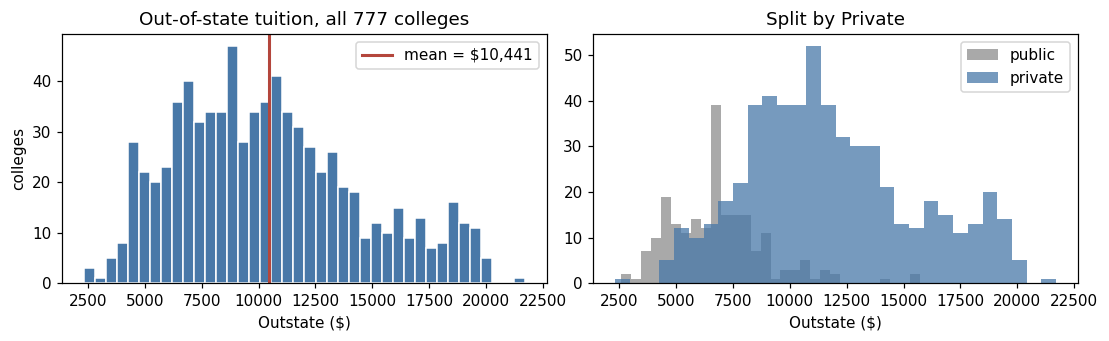

In [5]:
print(y_all.describe().round(0).to_string())
print(f'\nstandard deviation of Outstate: ${y_all.std():,.0f}')

fig, ax = plt.subplots(1, 2, figsize=(10, 3.2))
ax[0].hist(y_all, bins=40, color='#4878A8', edgecolor='white')
ax[0].axvline(y_all.mean(), color='#B4463C', lw=2, label=f'mean = ${y_all.mean():,.0f}')
ax[0].set_xlabel('Outstate ($)'); ax[0].set_ylabel('colleges'); ax[0].legend()
ax[0].set_title('Out-of-state tuition, all 777 colleges')

for v, c, lab in [(0, '#8C8C8C', 'public'), (1, '#4878A8', 'private')]:
    ax[1].hist(y_all[X_all['Private'] == v], bins=30, alpha=.75, color=c, label=lab)
ax[1].set_xlabel('Outstate ($)'); ax[1].legend(); ax[1].set_title('Split by Private')
fig.tight_layout(); plt.show()

### The single fact that shapes this problem

The predictors are not remotely on a common scale — `Apps` runs into five figures while `S.F.Ratio` sits near 14 — and several of them measure **the same underlying thing**. Applications, acceptances, enrolments and full-time undergraduates are all proxies for *how big the institution is*, and they correlate above 0.8 with one another. That has two consequences you will meet later: any penalised method must be given **standardised** predictors, and individual coefficients inside the correlated block will be unstable and hard to interpret on their own.

In [6]:
scale = pd.DataFrame({'min': X_all.min(), 'median': X_all.median(), 'max': X_all.max(),
                      'sd': X_all.std()}).round(1)
print('Predictor scales\n'); print(scale.to_string())

size_block = ['Apps', 'Accept', 'Enroll', 'F.Undergrad']
print('\nThe size block — correlations among four measures of "how big is it"\n')
print(X_all[size_block].corr().round(3).to_string())

Predictor scales

                min  median      max      sd
Private         0.0     1.0      1.0     0.4
Apps           81.0  1558.0  48094.0  3870.2
Accept         72.0  1110.0  26330.0  2451.1
Enroll         35.0   434.0   6392.0   929.2
Top10perc       1.0    23.0     96.0    17.6
Top25perc       9.0    54.0    100.0    19.8
F.Undergrad   139.0  1707.0  31643.0  4850.4
P.Undergrad     1.0   353.0  21836.0  1522.4
Room.Board   1780.0  4200.0   8124.0  1096.7
Books          96.0   500.0   2340.0   165.1
Personal      250.0  1200.0   6800.0   677.1
PhD             8.0    75.0    103.0    16.3
Terminal       24.0    82.0    100.0    14.7
S.F.Ratio       2.5    13.6     39.8     4.0
perc.alumni     0.0    21.0     64.0    12.4
Expend       3186.0  8377.0  56233.0  5221.8
Grad.Rate      10.0    65.0    118.0    17.2

The size block — correlations among four measures of "how big is it"

              Apps  Accept  Enroll  F.Undergrad
Apps         1.000   0.943   0.847        0.814
Accep

## 2. The sealed test set

A 70/30 split at `random_state=2024`. **Do not touch `X_test` / `y_test` until you have finished modelling.** Every choice you make — which variables, which penalty, which transformation — must be justified by cross-validation on the *training* data. The moment a test-set number influences a modelling decision, your reported RMSE stops being an estimate of anything.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.30, random_state=2024)

print(f'train: {X_train.shape[0]} colleges x {X_train.shape[1]} predictors')
print(f'test:  {X_test.shape[0]} colleges   <-- SEALED until the final evaluation')
print(f'\nmean Outstate  train ${y_train.mean():,.0f}   (test mean withheld on purpose)')

train: 543 colleges x 17 predictors
test:  234 colleges   <-- SEALED until the final evaluation

mean Outstate  train $10,377   (test mean withheld on purpose)


## 3. The baseline you have to beat

The **null model** predicts the training mean for every college — it uses no information at all. Its test RMSE is therefore the scale of the problem: the typical error you make by knowing nothing but the average. Any model must beat it, and a model that does not has told you something real about the data.

In [8]:
null_pred = np.full(len(y_test), y_train.mean())
NULL_RMSE = float(np.sqrt(mean_squared_error(y_test, null_pred)))

print(f'null model (predict ${y_train.mean():,.0f} for everyone)')
print(f'  test RMSE      = ${NULL_RMSE:,.0f}')
print(f'  sd(Outstate)   = ${y_all.std():,.0f}   <-- the same idea across all 777 colleges;')
print('                             the RMSE above differs because it scores the *training*')
print('                             mean against a particular 234 held-out colleges.')
print('\nSo a model that knows nothing is wrong by roughly $4,000 at a typical college.')
print('Everything you build is judged against that figure, not against zero.')

null model (predict $10,377 for everyone)
  test RMSE      = $4,165
  sd(Outstate)   = $4,023   <-- the same idea across all 777 colleges;
                             the RMSE above differs because it scores the *training*
                             mean against a particular 234 held-out colleges.

So a model that knows nothing is wrong by roughly $4,000 at a typical college.
Everything you build is judged against that figure, not against zero.


### The two helpers

`cv_rmse()` is how you compare candidates **while deciding** — five-fold cross-validation on the training set, in dollars, seed fixed so your folds match everyone else's.

`evaluate()` is how you score a **finished** model, once. It touches the test set, so each call spends part of your credibility: use four or five in total, at the very end. `results_table()` collects what you have scored.

In [9]:
CV = KFold(n_splits=5, shuffle=True, random_state=2024)


def cv_rmse(model, columns=None, X=None, y=None):
    """Five-fold CV RMSE (dollars) on the TRAINING data. Use this to choose.

    model    : any unfitted sklearn estimator or pipeline
    columns  : list of predictor names, or None for all seventeen
    """
    X = X_train if X is None else X
    y = y_train if y is None else y
    if columns is not None:
        X = X[list(columns)]
    scores = cross_val_score(model, X, y, cv=CV,
                             scoring='neg_root_mean_squared_error')
    return float(-scores.mean())


RESULTS = {}


def evaluate(name, predictions):
    """Score finished test-set predictions. Call ONCE per final model, at the end."""
    pred = np.asarray(predictions, dtype=float).ravel()
    if pred.shape[0] != len(y_test):
        raise ValueError(f'expected {len(y_test)} predictions, got {pred.shape[0]} — '
                         'did you predict on X_train by mistake?')
    rmse = float(np.sqrt(mean_squared_error(y_test, pred)))
    RESULTS[name] = {'test_RMSE': round(rmse),
                     'vs_null': round(rmse / NULL_RMSE, 3),
                     'R2': round(r2_score(y_test, pred), 3)}
    print(f'{name:<32s} test RMSE = ${rmse:>7,.0f}   '
          f'({rmse / NULL_RMSE:.2f} x null,  R2 = {r2_score(y_test, pred):.3f})')
    return rmse


def results_table():
    """Everything scored so far, best first — paste this into your memo."""
    return (pd.DataFrame(RESULTS).T.sort_values('test_RMSE')
            if RESULTS else pd.DataFrame(columns=['test_RMSE', 'vs_null', 'R2']))


# Register the baseline so the table always has something to compare against.
evaluate('Null (training mean)', null_pred)
results_table()

Null (training mean)             test RMSE = $  4,165   (1.00 x null,  R2 = -0.003)


,test_RMSE,vs_null,R2
Null (training mean),4165.0,1.0,-0.003


---

# Your work starts here

Six steps. Each says what to produce and which chapter supplies the method. Add your own code cells beneath each heading.

## Step 1 — Look before you model  *(Chapter 2–3)*

Before fitting anything, form an expectation you can be wrong about. Which predictors look most strongly related to `Outstate`? Is the relationship plausibly linear, or does it bend? Are any predictors badly skewed — and if so, what does Chapter 3 say about transforming a skewed predictor?

Write down, in one or two sentences, **which five variables you expect to matter** before you have any evidence. You will compare that guess against the answer in Step 4, and the comparison is worth reporting either way.

## Step 2 — The colleague's model  *(Chapter 3)*

Fit ordinary least squares on **all seventeen** predictors, on the training data. Report:

- its five-fold `cv_rmse()` on the training set,
- the coefficients, with attention to the size block (`Apps`, `Accept`, `Enroll`, `F.Undergrad`) — do the signs make sense to you? can you explain to the board what a *negative* coefficient on one of them means?

Do **not** score it on the test set yet. Everything is scored together, in Step 5.

## Step 3 — Try to beat it  *(Chapters 5–6)*

Now bring the Chapter 6 machinery. At a minimum:

- **Ridge** and the **lasso**, on **standardised** predictors — use `make_pipeline(StandardScaler(), ...)` so that the scaling is refitted inside every CV fold rather than leaked across them. Choose the penalty by cross-validation (`RidgeCV`, `LassoCV(cv=5)`).
- **Subset selection** — forward stepwise is enough, scored by `cv_rmse()` at each size. Record the whole CV curve from one variable to seventeen, not only its minimum, and look at how *flat* it is.
- Optionally a transformation or two from Step 1, or splines from Chapter 7.

For each candidate, report the training CV RMSE and, for the lasso, **how many coefficients survived** and which are largest once the predictors are standardised. Then decide which single model is your **best**, on CV evidence alone.

Report what you tried, including whatever failed. The result you did not expect is the one worth the most marks.

## Step 4 — The board's five variables  *(Chapter 6)*

Choose **exactly five** predictors by a stated procedure and fit OLS on them.

Some options, all defensible if you say which you used and why: forward stepwise stopped at five; exhaustive best-subset of size five scored by `cv_rmse()`; the five largest standardised lasso coefficients. They will not all give the same five. If you have time, run **two** of them and explain the disagreement — that explanation is the strongest thing this project can contain.

Then check the model is fit to be shown to a board: are its coefficients signed the way a lay reader would expect, and can you state each one in a sentence of the form "a $1,000 increase in X is associated with …"?

## Step 5 — Break the seal  *(Chapter 5)*

Only now. Call `evaluate()` once for each final model — the all-seventeen OLS, your best model, your five-variable model, and at most one or two others — then print `results_table()`.

Compute **the cost of the restriction**: five-variable test RMSE minus best-model test RMSE, in dollars. Put it in context two ways:

- as a fraction of the null model's RMSE, and
- as a fraction of the improvement over the null that your best model achieves.

Then ask the harder question: with 234 test colleges, **is that gap distinguishable from zero?** A bootstrap of the test-set squared errors, or the standard error of the RMSE difference, will tell you. A cost you cannot distinguish from zero is a very different recommendation from one you can.

## Step 6 — The memo  *(the deliverable)*

Replace the placeholder cell below with your one-page memo to the consortium's board. It must contain all seven required items from the README's table: the four RMSEs, the five variables and how they were chosen, the dollar cost of the restriction with one relative framing, and your recommendation with its single most dangerous caveat.

Write it for the board's chair, not for your instructor: no code, no undefined abbreviations, dollars rounded to whole numbers, and one clear sentence saying which model the consortium should publish.

### MEMO — replace this cell

**To:** Board of the university consortium
**From:** (your name)
**Subject:** Out-of-state tuition — model recommendation

*Delete this placeholder and write your memo here.*

| Model | Test RMSE |
|---|---|
| Null (training mean) | $… |
| All seventeen variables | $… |
| Best model — (name it) | $… |
| Five variables — (list them) | $… |

**Cost of the restriction to five variables:** $…, which is …% of the null model's error and …% of the gain the full model buys over the null.

**Recommendation:** …

**Caveat:** …